In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score, roc_curve
from sklearn.preprocessing import StandardScaler, LabelEncoder

In [2]:
df = pd.read_csv("titanic.csv")

In [3]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [5]:
df.drop(columns = ["Name", "Ticket","PassengerId", "Cabin"],inplace = True)

In [6]:
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])


In [7]:
df.isnull().sum()

Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64

In [8]:
df['Sex'] = LabelEncoder().fit_transform(df['Sex'])
df = pd.get_dummies(df, columns = ['Embarked'], drop_first = True)

In [9]:
df['FamilySize'] = df['SibSp']+df['Parch']+1
df.drop(columns = ['SibSp', 'Parch'], inplace = True)

In [10]:
df.head()

,Survived,Pclass,Sex,Age,Fare,Embarked_Q,Embarked_S,FamilySize
0,0,3,1,22.0,7.2500,False,True,2
1,1,1,0,38.0,71.2833,False,False,2
2,1,3,0,26.0,7.9250,False,True,1
3,1,1,0,35.0,53.1000,False,True,2
4,0,3,1,35.0,8.0500,False,True,1


In [11]:
scaler = StandardScaler()
scaled_features = scaler.fit_transform(df.drop("Survived", axis=1))
X = pd.DataFrame(scaled_features, columns = df.drop('Survived', axis =1).columns)
y = df['Survived']

In [12]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 42)


In [13]:
model = LogisticRegression()
params = {
    'C': [0.01, 0.1, 1, 10],
    'solver': ['liblinear', 'lbfgs']
}
grid = GridSearchCV(model, param_grid = params,cv=5, scoring = 'accuracy')
grid.fit(X_train, y_train)

best_model = grid.best_estimator_

In [14]:
y_pred = best_model.predict(X_test)

print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Accuracy:", accuracy_score(y_test, y_pred))

Confusion Matrix:
 [[136  21]
 [ 31  80]]
Classification Report:
               precision    recall  f1-score   support

           0       0.81      0.87      0.84       157
           1       0.79      0.72      0.75       111

    accuracy                           0.81       268
   macro avg       0.80      0.79      0.80       268
weighted avg       0.81      0.81      0.80       268

Accuracy: 0.8059701492537313


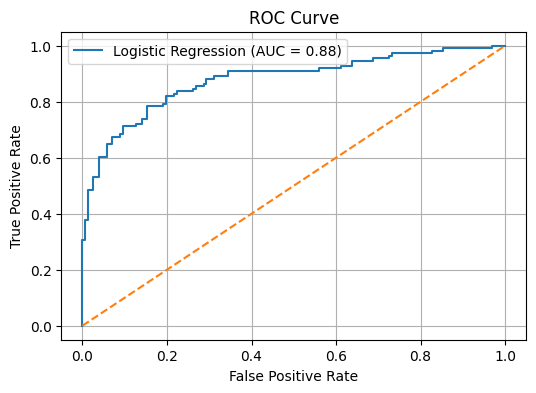

In [15]:
y_probs = best_model.predict_proba(X_test)[:, 1]
auc_score = roc_auc_score(y_test, y_probs)
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label = f"Logistic Regression (AUC = {auc_score:.2f})")
plt.plot([0, 1], [0, 1], linestyle = '--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(("ROC Curve"))
plt.legend()
plt.grid()
plt.show()

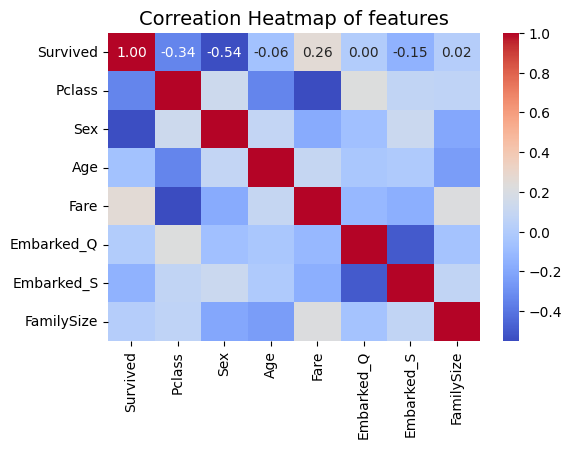

In [16]:
plt.figure(figsize =(6, 4))
sns.heatmap(df.corr(), annot= True, cmap = 'coolwarm', fmt= '.2f')
plt.title("Correation Heatmap of features", fontsize = 14)
plt.show()

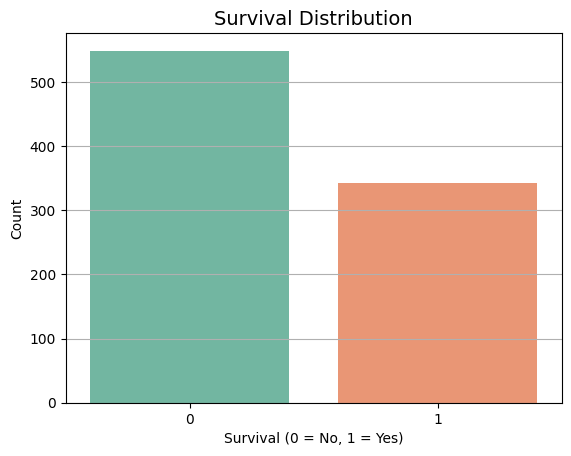

In [17]:
sns.countplot(x= 'Survived', data = df, palette = 'Set2')
plt.title("Survival Distribution", fontsize =14)
plt.xlabel("Survival (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.grid(axis = 'y')
plt.show()

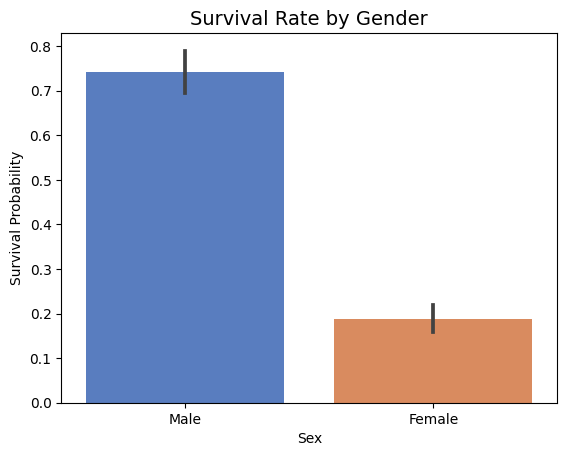

In [18]:
sns.barplot(x = 'Sex', y='Survived', data = df, palette = 'muted')
plt.xticks([0, 1], ['Male', 'Female'])
plt.title("Survival Rate by Gender", fontsize =14)
plt.ylabel("Survival Probability")
plt.show()

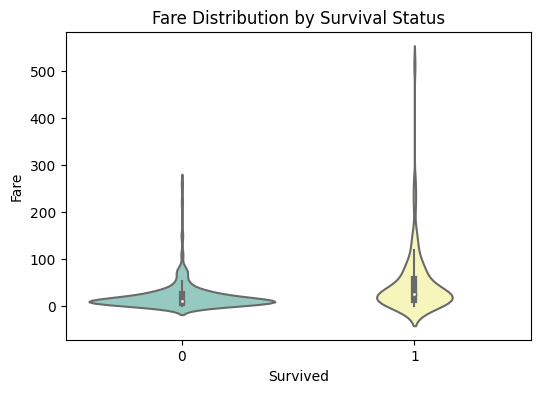

In [19]:
plt.figure(figsize = (6, 4))
sns.violinplot(x = "Survived", y="Fare", data = df, palette = 'Set3')
plt.title("Fare Distribution by Survival Status")
plt.xlabel("Survived")
plt.ylabel("Fare")
plt.show()

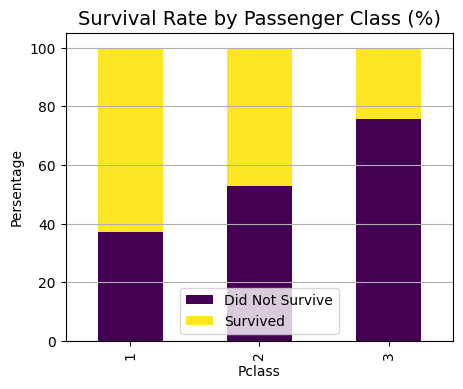

In [20]:
ct = pd.crosstab(df['Pclass'], df['Survived'], normalize='index')*100
ct.plot(kind = 'bar', stacked=True, colormap='viridis', figsize=(5, 4))
plt.title("Survival Rate by Passenger Class (%)", fontsize = 14)
plt.ylabel("Persentage")
plt.legend(["Did Not Survive", "Survived"])
plt.grid(axis = 'y')
plt.show()

Accuracy: 0.8059701492537313
Classification Report:
               precision    recall  f1-score   support

           0       0.81      0.87      0.84       157
           1       0.79      0.72      0.75       111

    accuracy                           0.81       268
   macro avg       0.80      0.79      0.80       268
weighted avg       0.81      0.81      0.80       268



C:\Users\thesw\AppData\Local\Temp\ipykernel_16028\3612281506.py:13: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].median(), inplace=True)
C:\Users\thesw\AppData\Local\Temp\ipykernel_16028\3612281506.py:14: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For

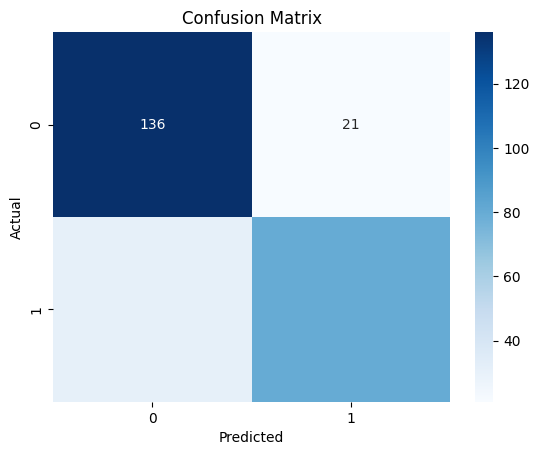

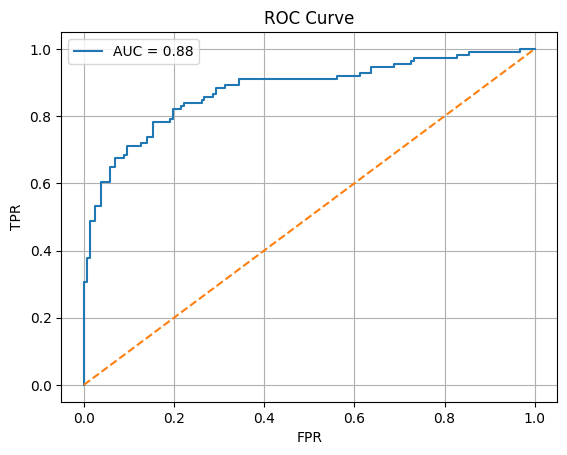

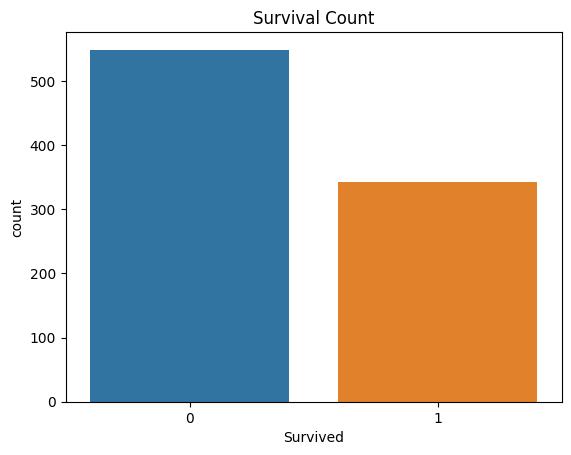

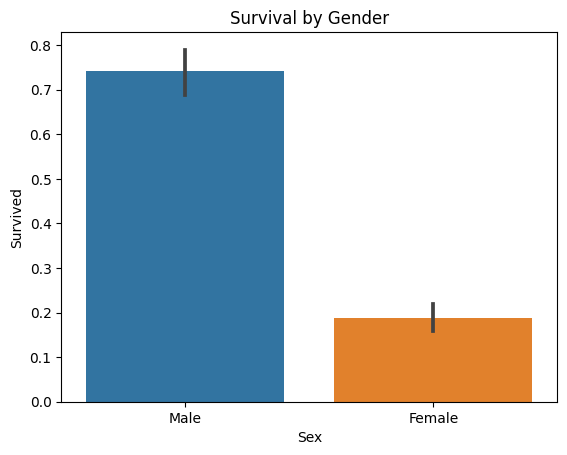

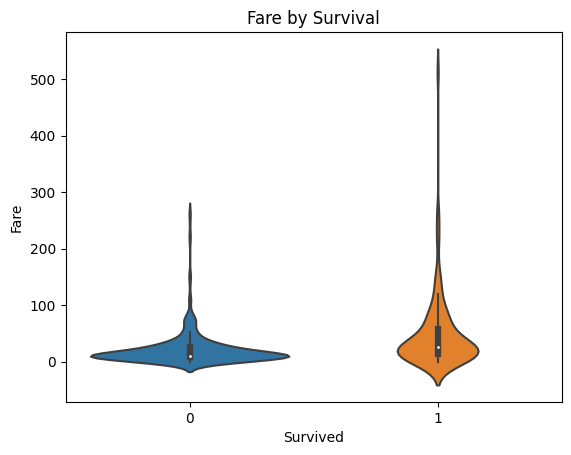

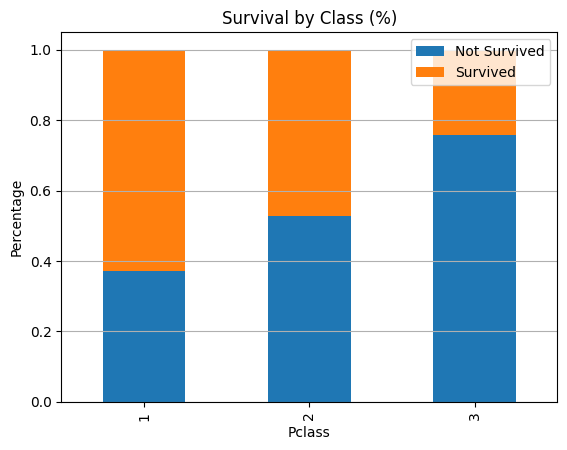

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score, roc_curve

# Load and clean data
df = pd.read_csv("titanic.csv")
df.drop(columns=["Name", "Ticket", "PassengerId", "Cabin"], inplace=True)
df['Age'].fillna(df['Age'].median(), inplace=True)
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)

# Encode categorical data and engineer features
df['Sex'] = LabelEncoder().fit_transform(df['Sex'])
df = pd.get_dummies(df, columns=['Embarked'], drop_first=True)
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
df.drop(columns=['SibSp', 'Parch'], inplace=True)

# Split and scale data
X = df.drop("Survived", axis=1)
y = df["Survived"]
X = StandardScaler().fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Train logistic regression model
model = LogisticRegression()
model.fit(X_train, y_train)

# Evaluate model
y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

# Confusion matrix
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# ROC Curve
y_probs = model.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_probs)
plt.plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_test, y_probs):.2f}")
plt.plot([0, 1], [0, 1], '--')
plt.title("ROC Curve")
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.legend()
plt.grid()
plt.show()

# Quick data visualizations
sns.countplot(x='Survived', data=df)
plt.title("Survival Count")
plt.show()

sns.barplot(x='Sex', y='Survived', data=df)
plt.xticks([0, 1], ['Male', 'Female'])
plt.title("Survival by Gender")
plt.show()

sns.violinplot(x='Survived', y='Fare', data=df)
plt.title("Fare by Survival")
plt.show()

pd.crosstab(df['Pclass'], df['Survived'], normalize='index').plot(kind='bar', stacked=True)
plt.title("Survival by Class (%)")
plt.ylabel("Percentage")
plt.legend(["Not Survived", "Survived"])
plt.grid(axis='y')
plt.show()
